## **Churn Business Case**
#### *Paula Ballesteros Fernández. 21st April 2026*

The file pretends to analyze a diverse customer base from a major international telecom company in order to answer some questions that may come to a solution for an existing issue: **a significant number of customers are leaving to their competitors and the company does not know who to contact first.**

**The questions are:**

- Understanding the key characteristics of customers who are likely to churn.
- Predicting the customer’s likelihood of leaving (churning).
- Identifying the top 500 customers to contact first – maximizing profitability and minimizing churn.
- Evaluating how your strategy compares to randomly contacting the business’ customers.

**Althought an extended analysis is developed throughout the sections, the answers to the main questions are summarized at the end of the file with the main conclusions.**

In [55]:
# Possible neccessary installs
# !pip install pandas numpy matplotlib geopandas seaborn scikit-learn scipy

In [56]:
# Imports 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from scipy.special import gammaln

In [57]:
# Data reading and first views 
data = pd.read_csv("churn_all.csv")
print(f"Data shape: {data.shape[0]} rows, {data.shape[1]} columns")
data.head(10)

Data shape: 5000 rows, 20 columns


,state,area_code,phone_number,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,Churn
0,KS,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,510,391-8027,yes,no,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,510,355-9993,no,yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,415,329-9001,yes,no,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,LA,408,335-4719,no,no,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
9,WV,415,330-8173,yes,yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False


An initial look at the dataset shows that the column representing the feature of interest is ***"Churn"***. Therefore, the analysis focuses on exploring the relationships between the other variables and this feature, and the predictive model will aim to predict the values of this column.

Firstly, let's study if the data has some inconsistencies (*Null* and duplicated values, inconsistent data types or impossible data combinations...).

In [58]:
# Null values and duplicates

# "phone_number" must be unique for a customer database based on mobile phone plans -- it could be consider as a "key column"
print('Duplicates on phone_number: ', data['phone_number'].duplicated().sum())
print('Duplicates on the entire dataset: ', data.duplicated().sum())

# Null values on some columns may lead to some errors, let's search for nulls on each column separately 
print('\nNull values per column:')
data.isnull().sum()

Duplicates on phone_number:  0
Duplicates on the entire dataset:  0

Null values per column:


state                            0
area_code                        0
phone_number                     0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
Churn                            0
dtype: int64

In [59]:
# Data types
# First look at the raw data types to check for any inconsistencies with the expected types based on the data views
data.dtypes

state                                str
area_code                          int64
phone_number                         str
international_plan                   str
voice_mail_plan                      str
number_vmail_messages              int64
total_day_minutes                float64
total_day_calls                    int64
total_day_charge                 float64
total_eve_minutes                float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_minutes              float64
total_night_calls                  int64
total_night_charge               float64
total_intl_minutes               float64
total_intl_calls                   int64
total_intl_charge                float64
number_customer_service_calls      int64
Churn                               bool
dtype: object

In [60]:
# Detection of inconsistencies like a client that has made lots of calls but has no minutes (that's not possible)

inconsistencies = []

# Calls > 0 but minutes == 0
for calls_col, minutes_col in [
    ("total_day_calls",   "total_day_minutes"),
    ("total_eve_calls",   "total_eve_minutes"),
    ("total_night_calls", "total_night_minutes"),
    ("total_intl_calls",  "total_intl_minutes"),
]:
    mask = (data[calls_col] > 0) & (data[minutes_col] == 0)
    inconsistencies.append({"check": f"{calls_col} > 0 but {minutes_col} == 0", "count": mask.sum()})

# Minutes > 0 but calls == 0
for calls_col, minutes_col in [
    ("total_day_calls",   "total_day_minutes"),
    ("total_eve_calls",   "total_eve_minutes"),
    ("total_night_calls", "total_night_minutes"),
    ("total_intl_calls",  "total_intl_minutes"),
]:
    mask = (data[minutes_col] > 0) & (data[calls_col] == 0)
    inconsistencies.append({"check": f"{minutes_col} > 0 but {calls_col} == 0", "count": mask.sum()})

# Voicemail messages > 0 but no voice_mail_plan
mask = (data["number_vmail_messages"] > 0) & (data["voice_mail_plan"] == "no")
inconsistencies.append({"check": "vmail_messages > 0 but no voice_mail_plan", "count": mask.sum()})

result = pd.DataFrame(inconsistencies)
result.style.apply(lambda x: ["background-color: #f6657a; color: white" 
                                if v > 0 else "" for v in x], subset=["count"])

,check,count
0,total_day_calls > 0 but total_day_minutes == 0,0
1,total_eve_calls > 0 but total_eve_minutes == 0,0
2,total_night_calls > 0 but total_night_minutes == 0,0
3,total_intl_calls > 0 but total_intl_minutes == 0,0
4,total_day_minutes > 0 but total_day_calls == 0,0
5,total_eve_minutes > 0 but total_eve_calls == 0,0
6,total_night_minutes > 0 but total_night_calls == 0,0
7,total_intl_minutes > 0 but total_intl_calls == 0,0
8,vmail_messages > 0 but no voice_mail_plan,0


Now that it has been seen that **data does not contain any inconsistency**, let's go throught the data explotation. 

---

We will study the relationship between most columns and whether a mobile phone customer churns or not in order to identify possible patterns or correlations in the data. For this analysis, we will exclude the column *"phone_number"*, since it only serves as a unique identifier for each client.

#### **1. General view of churn**

Let's look on how the column *Churn* is distributed, and so "how often is it a churn on the dataset".

In [61]:
churn_counts = data["Churn"].value_counts()
churn_pct = data["Churn"].mean() * 100
print(churn_counts)

# Churn rate on the global dataset
print(f"\nChurn rate: {churn_pct:.2f}%")

Churn
False    4293
True      707
Name: count, dtype: int64

Churn rate: 14.14%


Commonly, studies report that churn rates range between 11% and 22%, so an average value of around 15% is reasonable. This suggests that the dataset labels are not highly unbalanced and are within an acceptable range which represents a real-world context. (https://regulr.ai/blog/customer-churn-rate-by-industry)

#### **2. Numeric columns**

Let's look at some statistics of every numeric column and "filtering" by the phone numbers that have churned or not in a separate way, just to have some way to compare the different aspects on both cases.

In [62]:
# area_code does not represent quantifiable information, so general statistical analysis on it does not make sense
numeric_cols = [col for col in data.select_dtypes(include="number").columns if col != "area_code"]

statistics = data.groupby("Churn")[numeric_cols].mean().T
statistics.columns = ["Churn = False", "Churn = True"]
statistics["Difference (%) (Positive = Higher for True)"] = ((statistics["Churn = True"] - statistics["Churn = False"]) / statistics["Churn = False"] * 100).round(1)

# Color values to quickly show if churned clients' value is higher (red) or lower (green)
def color_clue(val):
    color = "green" if val > 0 else "red" if val < 0 else ""
    return f"color: {color}"

statistics.round(2).style.map(color_clue, subset=["Difference (%) (Positive = Higher for True)"])

,Churn = False,Churn = True,Difference (%) (Positive = Higher for True)
number_vmail_messages,8.290000,4.500000,-45.800000
total_day_minutes,175.750000,207.870000,18.300000
total_day_calls,122.970000,100.820000,-18.000000
total_day_charge,29.880000,35.340000,18.300000
total_eve_minutes,198.810000,211.760000,6.500000
total_eve_calls,100.240000,99.880000,-0.400000
total_eve_charge,16.900000,18.000000,6.500000
total_night_minutes,199.460000,206.080000,3.300000
total_night_calls,99.980000,99.580000,-0.400000
total_night_charge,8.980000,9.270000,3.300000


In [63]:
# Sum of churn occurrences per area_code may be a useful statistic for this column (showing its distribution in relation to churn)
area_code_data = data.groupby(["area_code", "Churn"]).size().unstack(fill_value=0)
area_code_data.columns = ["Churn = False", "Churn = True"]
# percentage of total churns it represents each area_code
area_code_data["% of total Churn"] = (area_code_data["Churn = True"] / area_code_data["Churn = True"].sum() * 100).round(1)
area_code_data

,Churn = False,Churn = True,% of total Churn
area_code,,,
408,1082,177,25.0
415,2149,346,48.9
510,1062,184,26.0


With these numerical statistics we can identify which features behave differently when comparing customers who churn and those who do not. For example, the column "total_day_calls" decreases by about 18% for customers who churn, while the opposite pattern appears in "total_day_minutes" and "total_day_charge", where the values increase. Similarly, "number_vmail_messages" decreases sharply by almost 46% for churned customers, while "number_customer_service_calls" increases by more than 50% in those cases.

On the other hand, the column "area_code" is also numeric but represents a very different and non-quantifiable concept. For this reason, the most logical statistic is to calculate the percentage represented by each code in both groups (customers who churn and those who do not). We can see that, although there are only three different area codes, one of them represents approximately 50% of the churned customers, while the other two appear with a more balanced distribution.

Overall, **this type of numerical analysis helps reveal patterns and differences between groups of customers, which can provide useful insights into the factors that may be related to customer churn.**

#### **3. State column (geographic aspect)**

Besides that, let’s study the geographical aspect: where the highest churn rates typically occur (percentage of churns relative to total subscriptions), and which states are therefore most affected by churn. We will analyze these rates both in a map visualization and numerically.

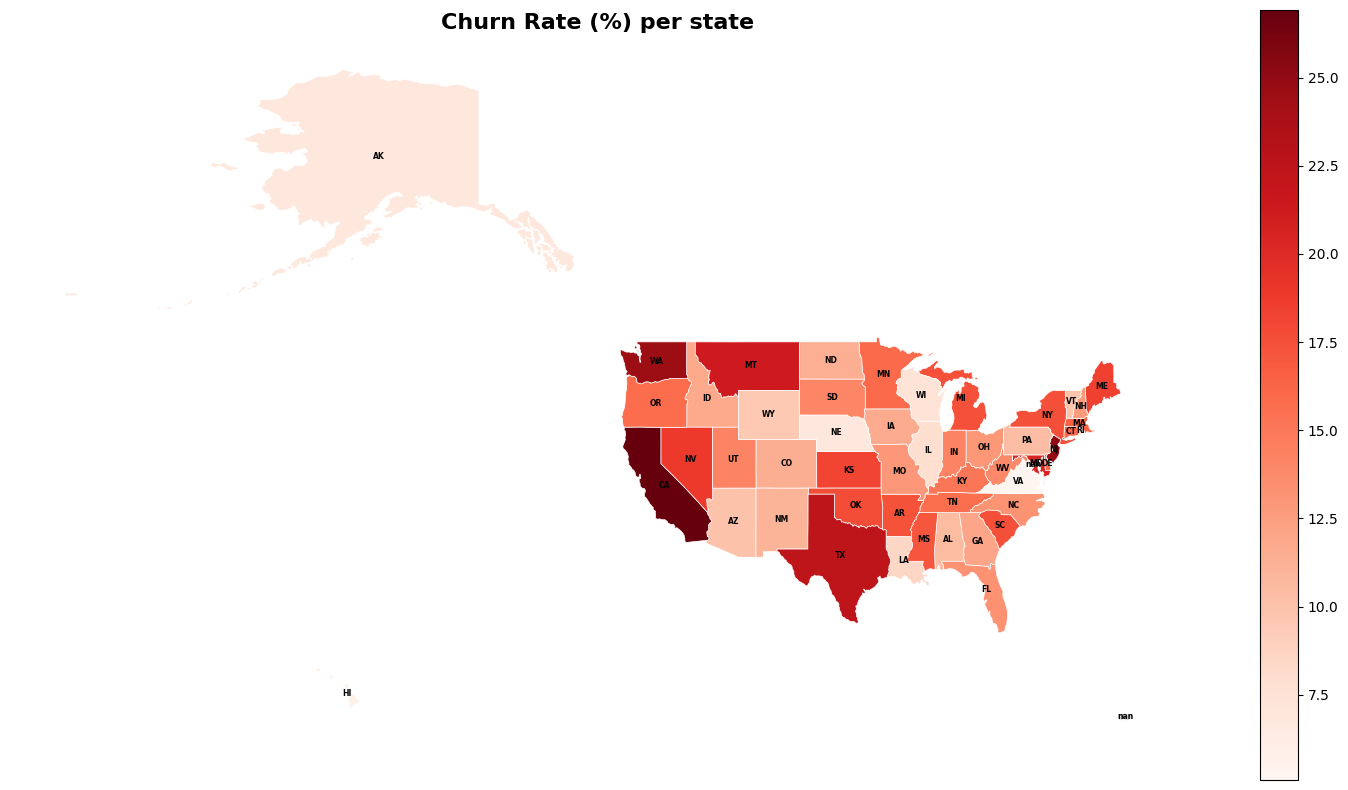

In [64]:
# Calculate churn rate per state
total_per_state = data.groupby("state").size().reset_index(name="total")
churned_per_state = data[data["Churn"] == True].groupby("state").size().reset_index(name="churned")
state_rates = total_per_state.merge(churned_per_state, on="state", how="left")
state_rates["churn_rate"] = (state_rates["churned"] / state_rates["total"] * 100).round(2)

# Common information for USA map visualization
usa = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")

abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO",
    "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

usa["abbrev"] = usa["name"].map(abbrev)
usa = usa.merge(state_rates, left_on="abbrev", right_on="state", how="left")

# Map visualization
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
usa.plot(column="churn_rate", ax=ax, legend=True, cmap="Reds",
         missing_kwds={"color": "lightgrey"}, edgecolor="white", linewidth=0.5)

# Add state code for easily identify each
for _, row in usa.iterrows():
    if row["abbrev"] is not None:
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, row["abbrev"],
                fontsize=5.5, ha="center", va="center", color="black", fontweight="bold")

ax.set_title("Churn Rate (%) per state", fontsize=16, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [65]:
# States above the benchmark churn rate - numerally
state_rates[state_rates["churn_rate"] > 14.14].sort_values("churn_rate", ascending=False).reset_index(drop=True)

,state,total,churned,churn_rate
0,CA,52,14,26.92
1,NJ,112,28,25.00
2,WA,98,24,24.49
3,TX,116,26,22.41
4,MT,99,21,21.21
5,MD,102,21,20.59
6,NV,90,17,18.89
7,ME,103,19,18.45
8,KS,99,18,18.18
9,OK,90,16,17.78


The map and the table below represent the same metric, the churn rate per state, from two complementary perspectives: one geographic and one numerical.

The map makes the spatial distribution immediately visible. Texas and California stand out as the darkest states, signalling the highest churn rates at a glance. Montana, Kansas, and Washington also appear in deep red, confirming they are among the most affected. On the east coast, New Jersey and Maine stand out noticeably against their neighbours.

In contrast, states like Florida, Georgia, and most of the Southeast appear light pink, suggesting structurally healthier retention relative to their customer base.

The table below complements the map by providing the exact figures. California leads at 26.9%, followed by Texas at 22.4%. States are filtered above the dataset benchmark of 14.14% to focus only on those where churn is structurally elevated, not just incidental noise from small samples.

Together, the map reveals where the problem is geographically concentrated while the table makes it precise and actionable.

#### **4. Boolean columns**

Furthermore, let’s examine whether there is any pattern or relationship between a customer subscribing to a service and their churn behavior.

In [66]:
for col in ["international_plan", "voice_mail_plan"]:
    data[col] = data[col].str.strip().str.lower()

boolean_data = data.groupby("Churn")[["international_plan", "voice_mail_plan"]].apply(lambda x: (x == "yes").sum())
boolean_data.index = ["Churn = False", "Churn = True"]

# Both plans are contracted at the same time (allows derived calculations to determine how often each plan is contracted individually)
boolean_data["both_yes"] = data.groupby("Churn").apply(lambda x: ((x["international_plan"] == "yes") & (x["voice_mail_plan"] == "yes")).sum()).values

boolean_data

,international_plan,voice_mail_plan,both_yes
Churn = False,274,1221,85
Churn = True,199,102,46


This table shows two opposite patterns. If we compare each partial value with the corresponding total value for the "Churn" column, we see that "international_plan" is strongly associated with churn: churned customers subscribe to it more than four times as often as retained customers. This suggests that the international plan may not be delivering enough value; for example, its pricing may be uncompetitive or the call quality may be poor, leading dissatisfied customers to leave.

On the other hand, "voice_mail_plan" shows the opposite pattern: retained customers use it at nearly double the rate of churned customers. This could indicate that the voice mail plan increases engagement and satisfaction, acting as a mild retention factor.

The both-plans combination follows the same pattern as the international plan, with churned customers subscribing to both plans more often than retained customers. This reinforces the idea that the international plan is the dominant driver of this signal rather than the voice mail plan. Overall, this suggests that these two variables are likely to be meaningful predictors in a churn model.

#### **5.Correlations**

Finally, let's see different correlations between columns: the correlation level of each column with the target one (*Churn*), and the correlation between all of them except the target one. 


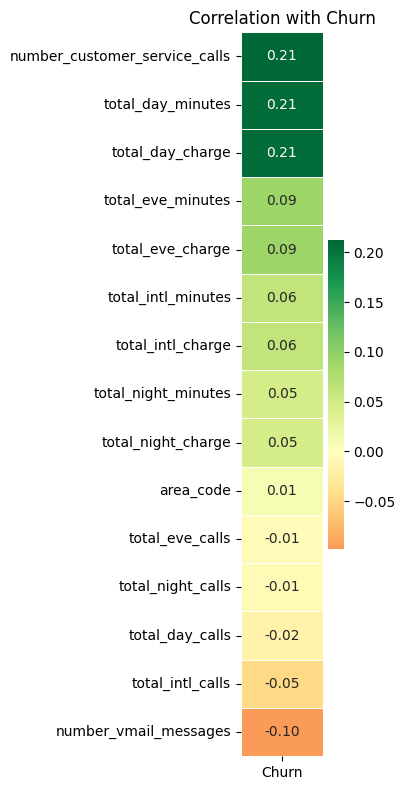

In [67]:
# Correlation level from all columns with "Churn"
corr = data.corr(numeric_only=True)[["Churn"]].drop("Churn").sort_values("Churn", ascending=False)

plt.figure(figsize=(4, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation with Churn")
plt.tight_layout()
plt.show()

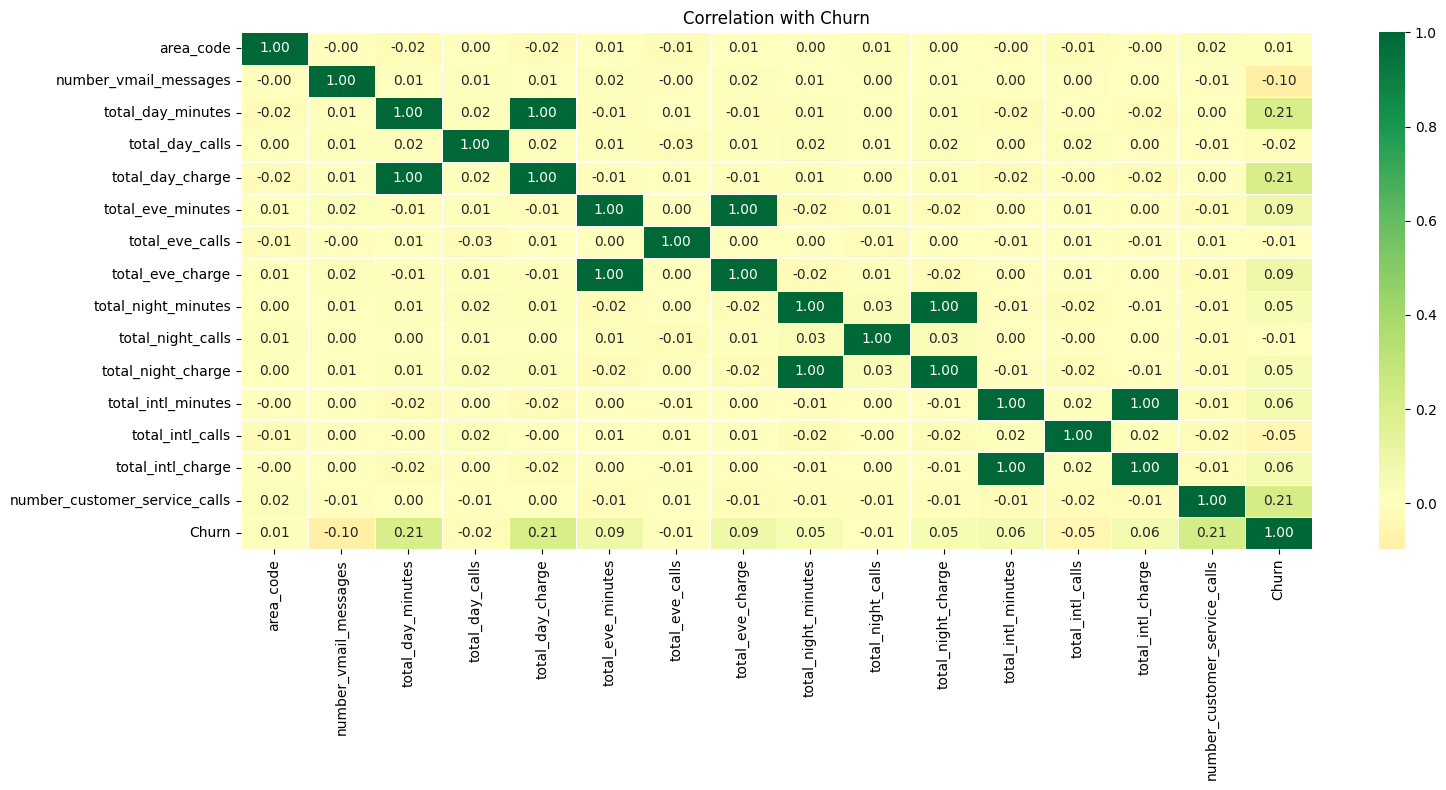

In [68]:
# and correlations between all columns to see if there are some of them which represent the same information 
corr = data.corr(numeric_only=True)

plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Correlation with Churn")
plt.tight_layout()
plt.show()

A correlation measures how much two variables tend to move together: when one increases, does the other also increase, decrease, or stay the same? A value close to 1 or -1 means a strong relationship (positive or negative), while a value close to 0 means the two variables are largely independent of each other. 

With this description, the first graphic shows that the three strongest positive predictors are tied at 0.21: number_customer_service_calls, total_day_minutes, and total_day_charge. A customer who calls support frequently or consumes a lot of daytime usage is somewhat more likely to churn. On the negative side, number_vmail_messages shows -0.10, consistent with the earlier finding that the voice mail plan acts as a mild retention factor — engaged voicemail users tend to stay.

Otherwise, the complete correlation matrix shows that the pairs **[total_day_minutes, total_day_charge], [total_eve_minutes, total_eve_charge], [total_night_minutes, total_night_charge], and [total_intl_minutes, total_intl_charge]** all show a correlation of 1.00: they are perfectly redundant because charge is calculated directly from minutes at a fixed rate. Including both variables from each pair in a model would add no new information and could cause issues in linear models; one from each pair should be dropped before modelling.

No single numerical feature is a strong predictor of churn on its own (max 0.21), which confirms that churn is a multi-factor phenomenon that will require combining several variables, and likely also the categorical ones already analysed will be needed to build a meaningful model.

---

### **Predicting client's churning probability**

The task is a binary classification problem: the goal is to predict whether a customer will churn (True) or not (False). Two modelling approaches will be explored. First, ***Logistic Regression***, chosen for its simplicity, speed, and interpretability, making it a solid baseline that is easy to understand and explain. It is also based on a linear model. Second, ***Random Forest***, a more powerful ensemble method that can capture non-linear relationships between variables that logistic regression might miss. Comparing both models allows us to evaluate whether the added complexity of *Random Forest* is justified by a meaningful improvement in predictive performance.

#### **1. Logistic Regression**

In [69]:
# Copy of the data for not missing information 
data_for_prediction = data.copy()

# Drop non-predictive columns
data_for_prediction.drop(columns=["phone_number", "state", "area_code", "total_day_minutes", 
                   "total_eve_minutes", "total_night_minutes", "total_intl_minutes"], inplace=True)

# Encode binary categoricals
for col in ["international_plan", "voice_mail_plan"]:
    data_for_prediction[col] = (data_for_prediction[col].str.strip() == "yes").astype(int)

# Target
data_for_prediction["Churn"] = data_for_prediction["Churn"].astype(int)

X = data_for_prediction.drop(columns="Churn")
y = data_for_prediction["Churn"]

# Train/test division
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model definition and training 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_sc, y_train)

# Churn likelihood (probability)
y_proba_lg = model.predict_proba(X_test_sc)[:, 1]

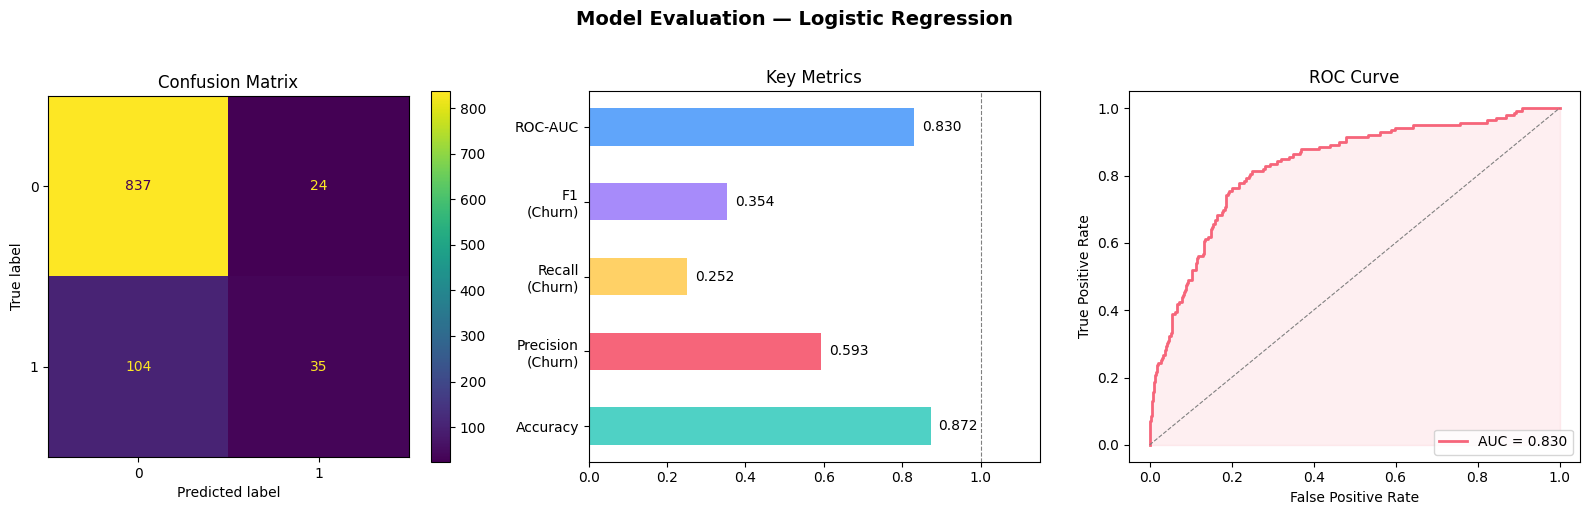

In [70]:
# Model prediction on test set
y_pred_lg = model.predict(X_test_sc)

# Metrics
report = classification_report(y_test, y_pred_lg, output_dict=True)
auc    = roc_auc_score(y_test, y_proba_lg)

# Representation - 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Evaluation — Logistic Regression", fontsize=14, fontweight="bold", y=1.02)

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lg, ax=axes[0])
axes[0].set_title("Confusion Matrix")

# 2. Key Metrics
metrics = {
    "Accuracy":  report["accuracy"],
    "Precision\n(Churn)": report["1"]["precision"],
    "Recall\n(Churn)":    report["1"]["recall"],
    "F1\n(Churn)":        report["1"]["f1-score"],
    "ROC-AUC":   auc
}
colors = ["#4fd1c5", "#f6657a", "#ffd166", "#a78bfa", "#60a5fa"]
bars = axes[1].barh(list(metrics.keys()), list(metrics.values()), color=colors, edgecolor="none", height=0.5)
axes[1].set_xlim(0, 1.15)
axes[1].set_title("Key Metrics")
axes[1].axvline(1.0, color="grey", linestyle="--", linewidth=0.8)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=10)

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_lg)
axes[2].plot(fpr, tpr, color="#f6657a", linewidth=2, label=f"AUC = {auc:.3f}")
axes[2].plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=0.8)
axes[2].fill_between(fpr, tpr, alpha=0.1, color="#f6657a")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

The model is evaluated using three complementary views: a confusion matrix, numerical metrics shown in a chart, and a ROC curve.

The confusion matrix shows the number of predictions divided into four categories: **true negatives** (correctly predicted no-churn), **true positives** (correctly predicted churn), **false positives** (predicted churn but the customer stayed), and **false negatives** (predicted no-churn but the customer actually left). This last category is the most costly in a churn context: a customer who leaves without being detected is a lost customer without any retention action being attempted. In this case, out of the **139 customers who actually churn**, the model only detects **35** and misses **104**, which represents a considerable weakness.

Regarding the metrics, several are worth highlighting. **Accuracy (0.872)** measures the proportion of correct predictions over the total number of cases, although it can be misleading because the dataset contains many more customers who do not churn than those who do. **Precision (0.593)** answers the question: of all the customers the model labels as churners, how many actually churn? A value of **0.593** means that when the model raises an alert, it is correct about **6 out of 10 times**, which is acceptable but could be improved. **Recall (0.252)** answers another important question: of all the customers who actually churn, how many does the model detect? This is the most critical metric from a business perspective. A low recall means that customers who were going to leave remain unnoticed and receive no retention action. A value of **0.252** means that only **1 out of 4 real churners** is detected, which is the main weakness of this model. Finally, the **F1 Score (0.354)** is the harmonic mean of Precision and Recall, summarizing the balance between the two in a single number. It penalizes imbalances: a model that performs well in one metric but poorly in the other will receive a low score. The value **0.354** reflects how the low recall reduces the overall performance on the churn class.

Finally, **ROC-AUC (0.830)** measures how well the model separates churners from non-churners across all possible decision thresholds, not only the default **0.5** threshold. A value of **0.5** is equivalent to random guessing, while **1.0** represents perfect separation. A value of **0.830** indicates solid discriminative ability. The gap between this relatively high AUC and the low recall suggests that the model is capable of ranking churners correctly, but the default threshold is too conservative given the class imbalance.


#### **2. Random Forest**

In [71]:
# Train on the same processed data as before
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

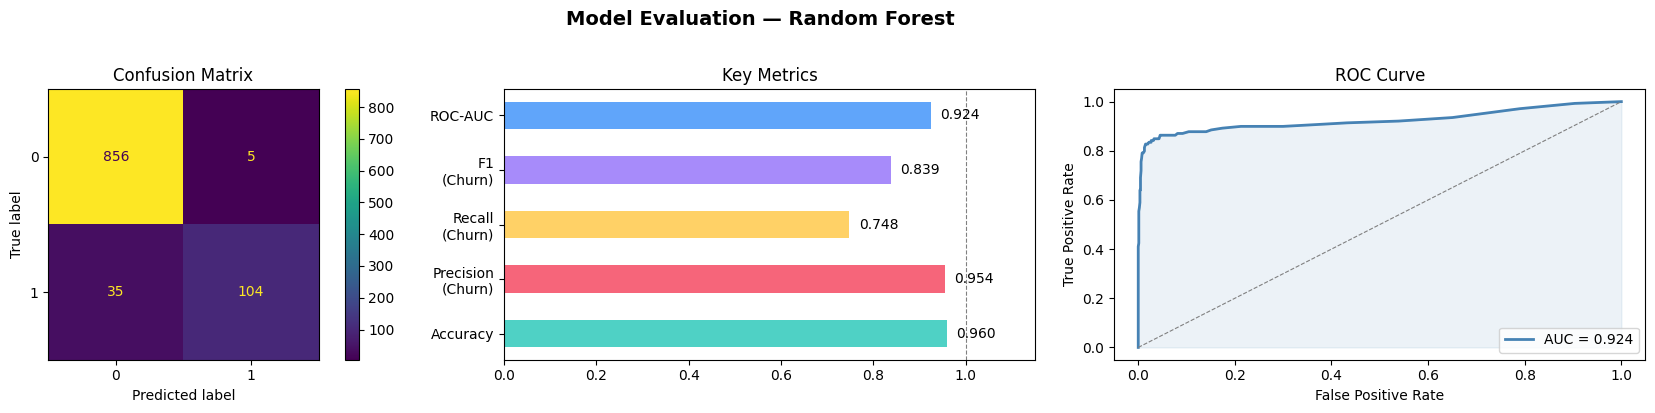

In [72]:
# Evaluate
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
report = classification_report(y_test, y_pred_rf, output_dict=True)
auc    = roc_auc_score(y_test, y_proba_rf)

# 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Model Evaluation — Random Forest", fontsize=14, fontweight="bold", y=1.02)

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[0])
axes[0].set_title("Confusion Matrix")

# 2. Key Metrics
metrics = {
    "Accuracy":  report["accuracy"],
    "Precision\n(Churn)": report["1"]["precision"],
    "Recall\n(Churn)":    report["1"]["recall"],
    "F1\n(Churn)":        report["1"]["f1-score"],
    "ROC-AUC":   auc
}
colors = ["#4fd1c5", "#f6657a", "#ffd166", "#a78bfa", "#60a5fa"]
bars = axes[1].barh(list(metrics.keys()), list(metrics.values()), color=colors, edgecolor="none", height=0.5)
axes[1].set_xlim(0, 1.15)
axes[1].set_title("Key Metrics")
axes[1].axvline(1.0, color="grey", linestyle="--", linewidth=0.8)
for bar, val in zip(bars, metrics.values()):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=10)

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
axes[2].plot(fpr, tpr, color="steelblue", linewidth=2, label=f"AUC = {auc:.3f}")
axes[2].plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=0.8)
axes[2].fill_between(fpr, tpr, alpha=0.1, color="steelblue")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

The model is evaluated using the same three complementary views: a confusion matrix, numerical metrics shown in a chart, and a ROC curve.

The confusion matrix shows this time that for the 139 real churners, the model now correctly detects 104 and only misses 35, compared to the logistic regression which detected just 35 and missed 104; essentially the opposite result. This improves the classification performance because fewer cases of customers who are going to churn are overlooked, making it possible to take action in time.

Regarding the metrics, they also reflect an improvement across the board. Accuracy jumps from 0.872 to 0.960, Precision from 0.593 to 0.954, Recall from 0.252 to 0.748, and F1 from 0.354 to 0.839. The most meaningful gain is in Recall: the model went from catching 1 in 4 churners to catching 3 in 4, which is the core objective of this problem. 

The **ROC-AUC improves** also from 0.830 **to 0.924**, and notably the curve rises steeply in the top-left corner, meaning the model achieves a very high true positive rate with very few false positives at low thresholds. It achieves a shape that reflects genuinely strong separation between classes, not just a marginally better ranking.

Overall, **Random Forest outperforms logistic regression** on every single metric, with the gap being especially large on the churn-specific ones that matter most from a business perspective (*Recall*). Let’s also analyze which columns or features have the greatest influence on the model’s decision.

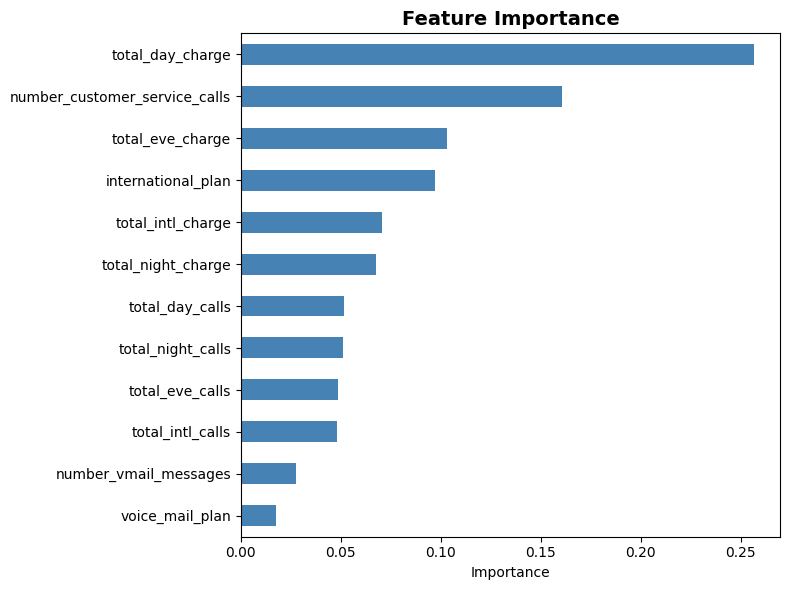

In [73]:
# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

***total_day_charge*** is by far the most influential variable. This could indicate that customers with higher daytime charges are more likely to churn, probably because they feel they are paying too much for the service. It is followed by *number_customer_service_calls*, which is consistent with the idea that a customer who repeatedly contacts customer support is expressing dissatisfaction before leaving.

In addition, *total_eve_charge* and *international_plan* rank third and fourth, reinforcing the findings from the previous exploratory analysis, where the international plan already showed a clear association with churn.

At the lower end, *voice_mail_plan* and *number_vmail_messages* have very little influence, confirming that although the voice mail plan may have a small protective effect, it is not a decisive predictor of churn.

Overall, the model suggests that churn is mainly driven by perceived cost (high charges) and service dissatisfaction (customer service calls), rather than by the volume of calls made.

---

### **Calculating the likelyhood of churning** - top 500 clients at risk

Now that Random Forest has been identified as the best-performing model, the next step is to use it to estimate the churn probability for individual customers based on their characteristics. Rather than simply predicting a binary outcome, the model outputs a probability score for each customer, which allows for a more nuanced prioritisation, focusing retention efforts on those most at risk. This analysis will be applied to the test set firstly, which contains customers the model has not seen during training, ensuring that the results reflect realistic predictive performance on new data.

In [74]:
# ── Business output: customers at risk ───────────────────────────────────────
THRESHOLD = 0.6  # lower threshold → catch more churners

X_test_copy = X_test.copy()
X_test_copy["churn_probability"] = y_proba_rf 
at_risk = X_test_copy[X_test_copy["churn_probability"] >= THRESHOLD].sort_values(
    "churn_probability", ascending=False
)

print(f"\nRisk clients (threshold {THRESHOLD}): {len(at_risk)} "
      f"({len(at_risk)/len(X_test_copy)*100:.1f}% of test set)")
print(at_risk[["churn_probability"]].head(10))


Risk clients (threshold 0.6): 85 (8.5% of test set)
      churn_probability
2099               0.97
2924               0.96
2696               0.91
3585               0.90
1934               0.89
605                0.88
3268               0.88
3686               0.88
4918               0.88
4628               0.88


A threshold has been set to determine from which probability a client is considered at risk. Let’s apply it to the whole dataset to identify the top 500 clients to contact first: those with the highest predicted probability of churn according to the model. The prediction needs to be done again by the model for the hole dataset.

In [75]:
# Evaluate
y_pred_complete  = rf.predict(X)
y_proba_complete = rf.predict_proba(X)[:, 1]

# ── Business output: customers at risk ───────────────────────────────────────
THRESHOLD = 0.7

X_copy = X.copy()
X_copy["phone_number"]      = data["phone_number"].values
X_copy["churn_probability"] = y_proba_complete

at_risk = X_copy[X_copy["churn_probability"] >= THRESHOLD].sort_values(
    "churn_probability", ascending=False
).head(500)

print(f"\nRisk clients (threshold {THRESHOLD}): {len(at_risk)} "
      f"({len(at_risk)/len(X_copy)*100:.1f}% of dataset)")
print(at_risk[["phone_number", "churn_probability"]])


Risk clients (threshold 0.7): 500 (10.0% of dataset)
     phone_number  churn_probability
552      419-8987               0.99
933      368-7555               0.99
1484     343-5219               0.99
126      335-4858               0.99
4803     382-2277               0.99
...           ...                ...
3667     420-7243               0.76
1405     366-5829               0.76
4067     397-2769               0.76
4355     396-3744               0.76
2150     336-8343               0.75

[500 rows x 2 columns]


In [76]:
# Extract the phone_numbers of the top 500 clients at risk that need to be contacted first
print(at_risk["phone_number"].tolist())

[' 419-8987', ' 368-7555', ' 343-5219', ' 335-4858', ' 382-2277', ' 364-9904', ' 419-1714', ' 384-7176', ' 373-1223', ' 373-6922', ' 418-7055', ' 374-9107', ' 402-1251', ' 372-3750', ' 371-9388', ' 332-2650', ' 393-8762', ' 366-1084', ' 413-2194', ' 378-7878', ' 395-3867', ' 365-3009', ' 379-3484', ' 348-6853', ' 417-4456', ' 372-6497', ' 388-1386', ' 398-5195', ' 348-5830', ' 409-4734', ' 403-9167', ' 383-2254', ' 346-7656', ' 331-5650', ' 359-5574', ' 360-1171', ' 335-4888', ' 419-5171', ' 387-2084', ' 357-6039', ' 409-3198', ' 352-6976', ' 358-4500', ' 335-1874', ' 342-7953', ' 398-8927', ' 364-6617', ' 357-5946', ' 387-5453', ' 376-8749', ' 367-3220', ' 352-3832', ' 406-2551', ' 354-8492', ' 346-4157', ' 393-4823', ' 365-2008', ' 421-1326', ' 406-2866', ' 359-4336', ' 373-8908', ' 335-2019', ' 391-1025', ' 350-7114', ' 335-2967', ' 343-2592', ' 411-4648', ' 355-2464', ' 367-3275', ' 332-6181', ' 345-3787', ' 341-7686', ' 376-4292', ' 329-6731', ' 375-3826', ' 401-6982', ' 330-4402'

Once we have identified once the top 500 clients at risk, it is added a functionality in which it is taken into account the charge a client implies to the company. **The order of the top 500 clients is now decided as a combination of their probability to churn with the value they have for the company.**

In [77]:
# Evaluate
y_pred_complete  = rf.predict(X)
y_proba_complete = rf.predict_proba(X)[:, 1]

# ── Business output: customers at risk ───────────────────────────────────────
THRESHOLD = 0.7

X_copy = X.copy()
X_copy["phone_number"]      = data["phone_number"].values
X_copy["churn_probability"] = y_proba_complete
X_copy["total_day_charge"]  = data["total_day_charge"].values

# Priority score: expected daily revenue at risk per customer
X_copy["priority_score"] = X_copy["churn_probability"] * X_copy["total_day_charge"]

at_risk = (
    X_copy[X_copy["churn_probability"] >= THRESHOLD]
    .sort_values("priority_score", ascending=False)
    .head(500)
    .reset_index(drop=True)
)
at_risk.index += 1  # Priority rank starts at 1

print(f"\nRisk clients (threshold {THRESHOLD}): {len(at_risk)} "
      f"({len(at_risk)/len(X_copy)*100:.1f}% of dataset)\n")
print(at_risk[["phone_number", "churn_probability", "total_day_charge", "priority_score"]])


Risk clients (threshold 0.7): 500 (10.0% of dataset)

    phone_number  churn_probability  total_day_charge  priority_score
1       406-2551               0.96             59.76         57.3696
2       343-5709               0.95             59.64         56.6580
3       384-7176               0.98             57.53         56.3794
4       332-6181               0.95             56.83         53.9885
5       393-4823               0.96             56.07         53.8272
..           ...                ...               ...             ...
496     415-8448               0.77             22.46         17.2942
497     332-2650               0.98             17.60         17.2480
498     385-1622               0.90             19.14         17.2260
499     346-4157               0.96             17.90         17.1840
500     358-4500               0.97             17.68         17.1496

[500 rows x 4 columns]


In [78]:
# New list of ordered phone numbers
print(at_risk["phone_number"].tolist())

[' 406-2551', ' 343-5709', ' 384-7176', ' 332-6181', ' 393-4823', ' 331-5650', ' 345-9140', ' 395-3867', ' 370-9116', ' 408-1861', ' 335-1874', ' 394-5489', ' 379-8681', ' 359-5574', ' 357-5946', ' 401-6982', ' 351-7269', ' 417-4456', ' 373-2053', ' 352-6976', ' 344-1970', ' 370-5527', ' 341-1191', ' 413-2194', ' 372-6497', ' 366-1084', ' 379-8644', ' 409-3198', ' 378-3625', ' 416-7124', ' 343-2592', ' 359-6232', ' 419-8987', ' 363-4527', ' 333-7631', ' 359-4336', ' 374-5353', ' 373-6922', ' 419-5171', ' 348-6853', ' 345-3787', ' 408-4836', ' 383-1657', ' 376-7004', ' 398-5195', ' 335-2967', ' 357-6039', ' 389-4608', ' 374-1981', ' 395-1013', ' 379-3484', ' 371-9388', ' 383-2254', ' 409-1856', ' 355-2464', ' 406-4100', ' 396-1316', ' 373-7974', ' 345-1157', ' 334-5029', ' 382-2277', ' 367-3220', ' 387-2084', ' 419-1714', ' 406-2866', ' 385-4766', ' 373-8908', ' 335-2019', ' 389-3015', ' 373-4264', ' 348-5830', ' 398-8927', ' 406-7844', ' 348-1163', ' 397-7972', ' 335-4888', ' 387-5453'

It is shown that the order of the top 500 clients changes a bit when the value comes into it. Althought all the top clients have such a huge percentage of probability to churn. 

---

### **Comparison with random contacting**

To quantify the advantage of the model-based strategy, it is useful to measure what random calling would actually look like in practice. The following code simulates a scenario where, instead of using the model's prioritised list, the retention team calls customers in a completely random order. Three questions are answered: 

- What is the probability of reaching a target customer on any single call?
- What is the probability of having contacted every at-risk customer within a fixed call budget of 1,000 calls?
- How many random calls would be needed on average to complete the entire at-risk list?

The last question is estimated both analytically and through a simulation of 20,000 random orderings, producing a distribution that shows not just the average but how much variability there is around it. Together, these figures provide a concrete baseline to compare against the model strategy.

Total customers:   5000
Target customers:  500  (10.0% of dataset)

P(reach target | 1 random call): 0.1000  (10.00%)
Expected calls to reach all 500 targets: 4,991
P(all targets reached in ≤1000 calls): 0.0000%

Simulation (20,000 runs):
  Median calls to reach all targets: 4,994
  Mean calls:                        4,991
  P(all targets within 1000 calls): 0.00%


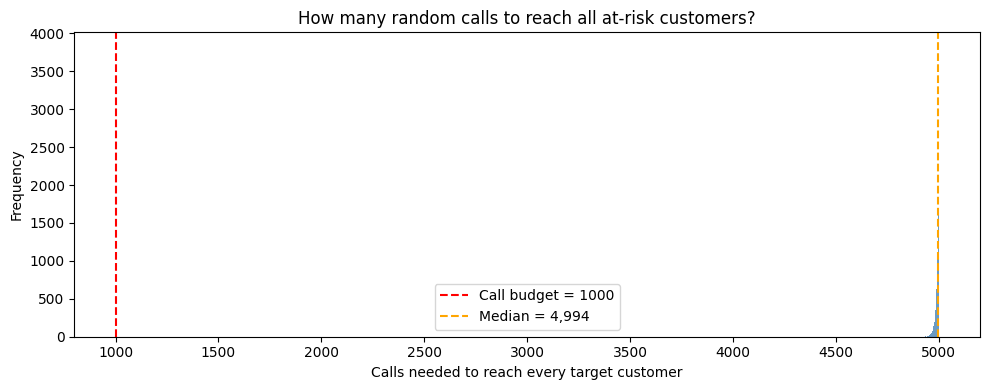

In [79]:
total     = len(data)       # total customers
target    = len(at_risk)    # at-risk customers
budget    = 1000            # call budget to evaluate

print(f"Total customers:   {total}")
print(f"Target customers:  {target}  ({target/total*100:.1f}% of dataset)")

# ── 1. Probability of hitting a target on a single random call
p_hit = target / total
print(f"\nP(reach target | 1 random call): {p_hit:.4f}  ({p_hit*100:.2f}%)")

# ── 2. Expected calls to reach every target customer
expected = target * (total + 1) / (target + 1)
print(f"Expected calls to reach all {target} targets: {expected:,.0f}")

# ── 3. P(all targets reached within budget) — analytical
if budget >= target:
    log_p = (gammaln(budget+1) - gammaln(budget-target+1)) - (gammaln(total+1) - gammaln(total-target+1))
    p_within_budget = np.exp(log_p)
else:
    p_within_budget = 0.0
print(f"P(all targets reached in ≤{budget} calls): {p_within_budget*100:.4f}%")

# ── 4. Simulation
N_SIMS = 20_000
is_target = np.zeros(total, dtype=bool)
is_target[:target] = True

calls_per_run = np.empty(N_SIMS, dtype=int)
for i in range(N_SIMS):
    order = np.random.permutation(total)
    calls_per_run[i] = np.where(is_target[order])[0][-1] + 1

print(f"\nSimulation ({N_SIMS:,} runs):")
print(f"  Median calls to reach all targets: {np.median(calls_per_run):,.0f}")
print(f"  Mean calls:                        {np.mean(calls_per_run):,.0f}")
print(f"  P(all targets within {budget} calls): {(calls_per_run <= budget).mean()*100:.2f}%")

# ── 5. Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(calls_per_run, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(budget, color="red", linestyle="--", linewidth=1.5,
           label=f"Call budget = {budget}")
ax.axvline(np.median(calls_per_run), color="orange", linestyle="--", linewidth=1.5,
           label=f"Median = {np.median(calls_per_run):,.0f}")
ax.set_xlabel("Calls needed to reach every target customer")
ax.set_ylabel("Frequency")
ax.set_title("How many random calls to reach all at-risk customers?")
ax.legend()
plt.tight_layout()
plt.show()

The results make the inefficiency of random calling immediately clear. With 500 at-risk customers out of a total of 5,000, each random call has a 10% chance of reaching a target — meaning 9 out of every 10 calls are wasted on customers who are not at such risk.

The consequences also arise when trying to reach the complete list. The expected number of random calls needed to contact all 500 targets is ~4,991, practically the entire customer base. The simulation of 20,000 runs confirms this: the median is 4,994 calls and the distribution is extremely concentrated near 5,000, as shown in the histogram where virtually all runs cluster at the far right. There is essentially no variability: random calling almost always requires contacting nearly everyone before the last target is reached.

The probability of completing the list within a budget of 1,000 calls is 0.00%: almost impossible. The red line on the histogram sits completely isolated on the left, separated from the distribution by a gap of nearly 4,000 calls.

This contrasts sharply with the model strategy: by sorting customers by predicted churn probability and targeting the top 500, all target customers are reached in exactly 500 calls — a 10x reduction in effort. The simulation does not just justify using the model; it demonstrates that random calling is not a viable alternative at any realistic call budget.

---

### **Final Summary and answers to initial questions**

**1. Key characteristics of customers likely to churn**

The analysis consistently points to two main drivers: **high daytime charges and frequent customer service calls**. Customers on the international plan churn at more than four times the rate of those without it, and geographic clustering shows that states such as California, New Jersey, and Washington have structural retention problems above 24%. Customers with a voice mail plan churn at roughly half the rate of those without one.

**2. Predicting the likelihood of churning**

**A **Random Forest** model was trained and selected over logistic regression based on its superior performance across all metrics.** It achieves a Recall of 0.748, a Precision of 0.954, and a ROC-AUC of 0.924; meaning it correctly identifies 3 out of 4 real churners while generating almost no false alarms. Each customer in the dataset is assigned an individual churn probability score that reflects their specific combination of characteristics.

**3. Top 500 customers to contact first**

Applying a threshold of 0.7 to the model's probability scores and ranking by a **priority score** — defined as `churn_probability × total_dia_charge` — produces a business-weighted list of the 500 highest-risk customers. This approach ensures that customers with both a high likelihood of churning and a high daily revenue contribution are contacted first, maximising the financial return on any retention investment.

**4. Model strategy vs. random contact**

Random calling has a 10% chance per call of reaching a target customer and requires approximately 4,991 calls to cover the full at-risk list, practically the entire customer base. The probability of completing the list within 1,000 random calls is 0%. The model strategy reaches all 500 priority targets in 500 calls, eliminating wasted contact with customers who are neither at high risk nor high value.
